# SPECTRE field integrity: from a boundary to the island metric

VMEC assumes nested flux surfaces through the ideal-MHD assumption, so its equilibrium cannot show magnetic islands. [SPECTRE](https://gitlab.com/spectre-eq/spectre) solves for the magnetic field without that assumption. We can then assign a field integrity score, M, to the design, which basically says how big its islands are. This is done in two procedures:

```python
output = run_spectre(equilibrium, settings)
metrics = compute_field_integrity_metrics(output, equilibrium)
```

This notebook follows them step by step on one design of the dataset (`misc.vmecpp_wout_id = DcPhJsLe4Zv8aphYRMNhuRw`, three field periods), from its boundary to its `FieldIntegrityMetrics`:

1. **Resonance screen**: read the VMEC rotational transform and select the low-order rationals it crosses.
2. **Resolution**: choose the resolution SPECTRE needs to show their islands.
3. **Toroidal ladder**: solve the field, raising the toroidal resolution until it is converged.
4. **Chain search**: find one O-point and one X-point of the island chain of each selected crossing.
5. **Field integrity score**: score each chain from its Greene residues and the VMEC shear, and sum.
6. **The record**: the score, with what is needed to read it.

The transform of this design crosses two low-order rationals, and the higher-order chain turns out to be the larger one.

Everything runs on a laptop, on one core: the SPECTRE solve takes one to two minutes and about 3.5 GB of memory, the chain search two to three minutes more. By default the notebook loads these results from files instead. SPECTRE has to be installed, which `pip install` of this repository does from source (it needs a Fortran compiler, CMake, MPI, HDF5 and OpenBLAS).

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib

import numpy as np

from constellaration import forward_model
from constellaration.geometry import surface_rz_fourier
from constellaration.mhd import spectre, spectre_settings, vmec_utils
from constellaration.utils import visualization

The expensive steps write their result next to the notebook and load it on the next run. Set a flag to `True` to compute that step again.

In [2]:
CACHE_DIR = pathlib.Path.cwd().resolve() / "spectre_field_integrity_cache"
CACHE_DIR.mkdir(exist_ok=True)
EQUILIBRIUM_FILE = CACHE_DIR / "equilibrium.json"
SPECTRE_OUTPUT_FILE = CACHE_DIR / "spectre_output.json"
METRICS_FILE = CACHE_DIR / "field_integrity_metrics.json"

RUN_VMEC = False  # False: download the equilibrium the dataset publishes
RUN_SPECTRE = False
RUN_CHAIN_SEARCH = False

## The boundary

A boundary is a set of Fourier coefficients of R and Z. This one is copied from the dataset row of the design. The first figure is interactive (it needs a running notebook); the second shows the cross-section of the boundary on the two planes used below: the start of a field period, where the chains are searched, and half a field period on, where the Poincaré section is drawn.

In [3]:
boundary = surface_rz_fourier.SurfaceRZFourier.model_validate_json(
    '{"r_cos":[[0.0,0.0,0.0,0.0,1.0,0.0,-0.02702702702702703,0.0,0.0],[0.0,0.0,0.08978104821425961,-0.019465376230152362,0.17956209642851922,-0.019465376230152362,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]],"z_sin":[[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.08978104821425961,0.0064884587433841215,-0.17956209642851922,0.0064884587433841215,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]],"r_sin":null,"z_cos":null,"n_field_periods":3,"n_periodicity":1,"is_stellarator_symmetric":true}'
)
visualization.plot_surface(boundary)

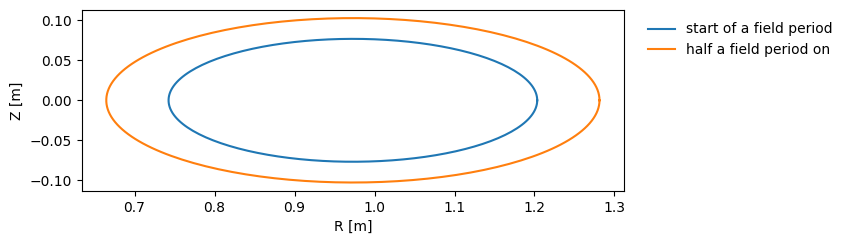

In [4]:
import matplotlib.pyplot as plt

from constellaration.geometry import surface_utils

# Two toroidal angles: the start of a field period and half a field period on.
theta_phi = surface_utils.make_theta_phi_grid(
    n_theta=200,
    n_phi=2,
    phi_upper_bound=np.pi / boundary.n_field_periods,
    include_endpoints=True,
)
rz = surface_rz_fourier.evaluate_points_rz(boundary, theta_phi)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(rz[:, 0, 0], rz[:, 0, 1], label="start of a field period")
ax.plot(rz[:, 1, 0], rz[:, 1, 1], label="half a field period on")
ax.set_xlabel("R [m]")
ax.set_ylabel("Z [m]")
ax.set_aspect("equal")
_ = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)

## The VMEC equilibrium

The dataset publishes the VMEC++ equilibrium of every design, so it is downloaded rather than solved again. With `RUN_VMEC = True` the forward model solves it here instead, at the fidelity the dataset was made with; that takes about ten minutes and gives the same rotational transform to nine digits.

In [5]:
WOUT_ID = "DcPhJsLe4Zv8aphYRMNhuRw"

if EQUILIBRIUM_FILE.exists() and not RUN_VMEC:
    equilibrium = vmec_utils.VmecppWOut.model_validate_json(
        EQUILIBRIUM_FILE.read_text()
    )
elif RUN_VMEC:
    settings = forward_model.ConstellarationSettings.default_high_fidelity_skip_qi()
    _, equilibrium = forward_model.forward_model(boundary, settings=settings)
    EQUILIBRIUM_FILE.write_text(equilibrium.model_dump_json())
else:
    import huggingface_hub
    import pyarrow.parquet as pq

    def download(filename):
        return huggingface_hub.hf_hub_download(
            "proxima-fusion/constellaration", filename, repo_type="dataset"
        )

    # One file of a few hundred MB holds the equilibrium, among a hundred others.
    file_of_id = pq.read_table(
        download("vmecpp_wout/id_to_file_map.parquet"), filters=[("id", "=", WOUT_ID)]
    )
    shard = pathlib.Path(file_of_id.column("path")[0].as_py()).name
    row = pq.read_table(
        download(f"vmecpp_wout/{shard}"), filters=[("id", "=", WOUT_ID)]
    )
    # The published JSON is cached as it is: an equilibrium of the dataset does not
    # survive being written out again by ``model_dump_json``.
    EQUILIBRIUM_FILE.write_text(row.column("json")[0].as_py())
    equilibrium = vmec_utils.VmecppWOut.model_validate_json(
        EQUILIBRIUM_FILE.read_text()
    )

VMEC's flux surfaces on the plane half a field period from the first one. They are nested by construction.

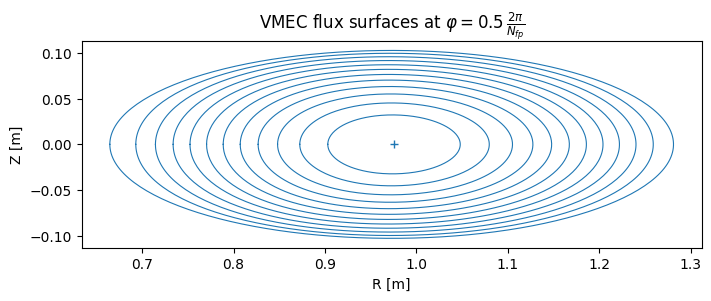

In [6]:
_ = visualization.plot_flux_surfaces_cross_section(
    equilibrium, normalized_toroidal_angle=0.5, figsize=(8, 3.5)
)

## The rotational transform and the rationals it crosses

An island chain can open where the rotational transform equals a rational n/m, with n a multiple of the number of field periods. The screen lists every such crossing with m up to `max_poloidal_order` (20 by default), lowest order first, and keeps the `max_rationals` lowest-order rationals. The order m is not a measure of the island's size; it is an entry screen, on the premise that a chain of order above 20 cannot hold a significant share of the flux.

`max_rationals` is 3 by default. Here it is set to 2 to keep the chain search short: the third rational of this design, 6/7, is crossed next to the magnetic axis, and its chain takes two more minutes to find for a score of 0.00007.

|iota| runs from 0.835 to 1.460
1. pairs (n, m) with m <= 20 and n/m in that range: 130
2. of which n is a multiple of N_fp = 3: 41
3. of which the first harmonic of their chain: 28
   3/3, 6/5, 6/7, 9/7, 9/8, 12/9, 9/10, 12/11, 15/11, 15/12, 12/13, 15/13, 18/13, 15/14, 21/15, 15/16, 21/16, 15/17, 18/17, 21/17, 24/17, 21/18, 18/19, 21/19, 24/19, 27/19, 21/20, 27/20
4. kept, the 2 of lowest order m: 3/3, 6/5


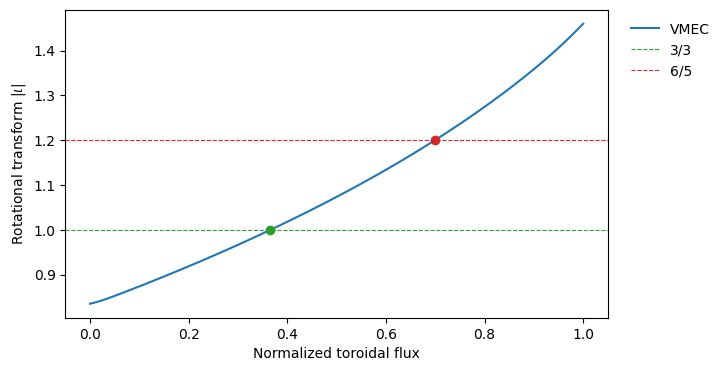

In [7]:
solver_settings = spectre_settings.SpectreSettings(max_rationals=2)
n_fp = equilibrium.n_field_periods
max_m = solver_settings.max_poloidal_order

iota = np.asarray(equilibrium.iotaf)
s_coordinate = equilibrium.normalized_toroidal_flux_full_grid_mesh
lowest, highest = np.abs(iota).min(), np.abs(iota).max()
print(f"|iota| runs from {lowest:.3f} to {highest:.3f}")

# 1. Every pair (n, m) with m <= max_poloidal_order and n/m inside that range.
in_range = [
    (n, m)
    for m in range(1, max_m + 1)
    for n in range(1, int(highest * m) + 1)
    if lowest < n / m < highest
]
print(f"1. pairs (n, m) with m <= {max_m} and n/m in that range: {len(in_range)}")

# 2. The field repeats every field period, so it only carries n multiple of N_fp.
periodic = [(n, m) for n, m in in_range if n % n_fp == 0]
print(f"2. of which n is a multiple of N_fp = {n_fp}: {len(periodic)}")

# 3. (3, 3), (6, 6), (9, 9)... are harmonics of one chain; keep the first of each.
fundamental = [
    (n, m) for n, m in periodic if spectre._is_fundamental_harmonic(n, m, n_fp)
]
print(f"3. of which the first harmonic of their chain: {len(fundamental)}")
print("   " + ", ".join(f"{n}/{m}" for n, m in fundamental))

# 4. The max_rationals lowest-order ones are kept, with where they are crossed.
refusal, crossings = spectre.screen_rotational_transform(
    iota, s_coordinate, n_fp, solver_settings
)
kept = sorted({(r.m, r.n) for r in crossings})
print(
    f"4. kept, the {solver_settings.max_rationals} of lowest order m: "
    + ", ".join(f"{n}/{m}" for m, n in kept)
)
_ = visualization.plot_rotational_transform(equilibrium, crossings, figsize=(7, 4))

Each selected crossing carries what the metric needs from VMEC: where it is, and the shear of the unperturbed profile there.

In [8]:
for r in crossings:
    print(
        f"iota = {r.n}/{r.m}: m = {r.m}, n = {r.n},"
        f" N_fp = {equilibrium.n_field_periods},"
        f" crossed at psi_n = {r.psi_n:.3f}, shear |d iota / d psi_n| = {r.shear:.3f}"
    )

iota = 3/3: m = 3, n = 3, N_fp = 3, crossed at psi_n = 0.366, shear |d iota / d psi_n| = 0.519
iota = 6/5: m = 5, n = 6, N_fp = 3, crossed at psi_n = 0.699, shear |d iota / d psi_n| = 0.699


## From VMEC to SPECTRE

The resolution follows the highest order selected: `mpol = max(14, 1.5 m)` poloidal modes and `lrad = mpol + 4` radial ones (`choose_resolution`). SPECTRE's own converter then turns the VMEC equilibrium into a SPECTRE input: one volume filled with a vacuum field, bounded by the same surface. `_build_spectre_input_parameters` adds the one thing the converter leaves out, the magnetic axis, which is set to VMEC's and pinned there.

In [9]:
mpol, lrad = spectre.choose_resolution(equilibrium, crossings, solver_settings)
ntor = solver_settings.toroidal_ladder[0]
parameters = spectre._build_spectre_input_parameters(
    equilibrium, solver_settings, mpol, ntor, radial_resolution=lrad
)
physics = parameters.physics
print(
    f"nvol = {physics.nvol}, mpol = {physics.mpol}, ntor = {physics.ntor},"
    f" lrad = {physics.lrad[0]}"
)
# The axis is a Fourier series in the toroidal angle: on the plane at the start of a
# field period its harmonics add up, half a field period on they alternate in sign.
# Z = 0 on both planes.
signs = (-1.0) ** np.arange(len(physics.rac))
print(f"magnetic axis at the start of a field period: R = {np.sum(physics.rac):.4f} m")
print(f"magnetic axis half a field period on: R = {np.sum(signs * physics.rac):.4f} m")
print(f"axis pinned: {parameters.numeric.lrzaxis == 0}")

nvol = 1, mpol = 14, ntor = 14, lrad = 18
magnetic axis at the start of a field period: R = 0.9733 m
magnetic axis half a field period on: R = 0.9751 m
axis pinned: True


## The SPECTRE solve

`run_spectre` screens the transform, builds that input and solves the field, climbing the toroidal resolutions 14, 18, 22, 26 until the Beltrami residual (how well the field satisfies its equation) is below the tolerance. It returns a `SpectreOutput` holding SPECTRE's complete HDF5 file, so the metrics can be recomputed later without solving again.

The solve runs in a child process of the notebook kernel, on one core.

In [10]:
if SPECTRE_OUTPUT_FILE.exists() and not RUN_SPECTRE:
    spectre_output = spectre.SpectreOutput.model_validate_json(
        SPECTRE_OUTPUT_FILE.read_text()
    )
else:
    spectre_output = spectre.run_spectre(equilibrium, solver_settings)
    SPECTRE_OUTPUT_FILE.write_text(spectre_output.model_dump_json())

print(f"refusal class: {spectre_output.refusal_class.value}")
ladder = solver_settings.toroidal_ladder
residuals = spectre_output.beltrami_residuals
print(f"solves needed: {len(residuals)}, of the {len(ladder)} rungs of the ladder")
for ntor, residual in zip(ladder, residuals):
    print(
        f"  mpol = {mpol}, ntor = {ntor}, lrad = {lrad}:"
        f" Beltrami residual {residual:.1e}"
        f" (tolerance {solver_settings.stop_residual:.0e})"
    )
print(f"HDF5 file: {len(spectre_output.h5_file) / 1e6:.1f} MB")

refusal class: NONE
solves needed: 1, of the 4 rungs of the ladder
  mpol = 14, ntor = 14, lrad = 18: Beltrami residual 2.4e-04 (tolerance 2e-02)
HDF5 file: 11.9 MB


## The field integrity metrics

`compute_field_integrity_metrics` searches, in the solved field, one O-point and one X-point of the chain at each selected crossing, and reads their Greene residues $R_O$ and $R_X$ from SPECTRE's tangent map. Each chain is scored

$$M = \frac{4}{\pi}\,\frac{{\color{blue}{N_{fp}}}\;|{\color{orange}{R_O}}\,{\color{orange}{R_X}}|^{1/4}}{{\color{blue}{m}}^2\,|{\color{blue}{d\iota/d\psi_n}}|}$$

where the quantities in ${\color{blue}{\text{blue}}}$ are read from the VMEC equilibrium (the number of field periods, the order of the rational and the shear at the crossing) and those in ${\color{orange}{\text{orange}}}$ from the SPECTRE field. M is the full width of the chain's islands as a fraction of the toroidal flux. The field integrity score of the design is the sum over its chains: between 0 and 1, 0 meaning no island and 1 islands from the axis to the boundary.

In [11]:
if METRICS_FILE.exists() and not RUN_CHAIN_SEARCH:
    metrics = spectre.FieldIntegrityMetrics.model_validate_json(
        METRICS_FILE.read_text()
    )
else:
    metrics = spectre.compute_field_integrity_metrics(spectre_output, equilibrium)
    METRICS_FILE.write_text(metrics.model_dump_json())

for chain in metrics.chains:
    print(
        f"{chain.n}/{chain.m}: R_O = {chain.residue_o:+.3e},"
        f" R_X = {chain.residue_x:+.3e},"
        f" |R_X/R_O| = {abs(chain.residue_x / chain.residue_o):.3f},"
        f" M = {chain.score:.4f}"
    )
print()
print(f"field integrity score M = {metrics.field_integrity_score:.4f}")
print(f"chains found: {len(metrics.chains)} of {len(metrics.crossings)}")
print(f"Beltrami residual: {metrics.beltrami_residual:.2e}")
print(f"refusal class: {metrics.refusal_class.value}")
print(
    "predicted destroyed flux, Delta Phi / Phi_edge ="
    f" {100 * spectre.predicted_flux_fraction(metrics.field_integrity_score):.1f} %"
)

3/3: R_O = +1.725e-03, R_X = -1.803e-03, |R_X/R_O| = 1.045, M = 0.0343
6/5: R_O = +5.085e-02, R_X = -5.244e-02, |R_X/R_O| = 1.031, M = 0.0497

field integrity score M = 0.0840
chains found: 2 of 2
Beltrami residual: 2.45e-04
refusal class: NONE
predicted destroyed flux, Delta Phi / Phi_edge = 5.4 %


The 6/5 chain is the larger of the two although 3/3 is the lower-order rational: scoring the lowest order alone would have reported less than half of this design's field integrity score.

## What VMEC could not show

The upper half of the figure is VMEC: nested surfaces, by assumption. The lower half is the same plane of the SPECTRE field, with field lines followed for 300 field periods. The section is up-down symmetric on this plane, so nothing is hidden by showing half of each. The O-points (circles) and X-points (crosses) are those of the two chains scored above, each chain in the colour of its rational in the figure of the rotational transform.

Three helpers for the figures below. They only read the solved field (SPECTRE's own `SPECTREout`, from `spectre.load_field`); the metrics do not use them.

In [12]:
def poincare_section(
    field, normalized_toroidal_angle=0.0, n_field_lines=60, n_punctures=300
):
    """Punctures of field lines of the solved field with one toroidal plane.

    Field lines are seeded evenly in the radial coordinate from the axis to the
    boundary and followed for ``n_punctures`` field periods. Returns one ``(n, 2)``
    array of (R, Z) per field line.
    """
    lines = []
    for s in np.linspace(-0.97, 0.99, n_field_lines):
        _, rz, _, _ = field.trace_one_fieldline(
            [float(s), 0.0],
            0,
            num_phi_planes=1,
            num_transits=n_punctures,
            zetan_start=normalized_toroidal_angle,
            rtol=1e-9,
            atol=1e-9,
        )
        points = np.asarray(rz, dtype=float).reshape(2, -1).T
        lines.append(points[np.isfinite(points).all(axis=1)])
    return lines


def chain_points(field, chain, on_half_period_plane=False):
    """Every O-point and X-point of a chain, as two ``(m, 2)`` arrays of (R, Z).

    The chain's record holds one point of each kind on the plane zeta = 0; following
    it for m field periods visits the other m - 1. ``on_half_period_plane`` returns
    the points on the plane half a field period on, the other stellarator-symmetric
    plane.
    """
    points = []
    for s, theta in (chain.o_point, chain.x_point):
        _, rz, _, _ = field.trace_one_fieldline(
            [s, theta],
            0,
            num_phi_planes=2,
            num_transits=chain.m,
            method="DOP853",
            rtol=1e-10,
            atol=1e-10,
        )
        rz = np.asarray(rz, dtype=float).reshape(2, -1).T
        points.append(rz[1 if on_half_period_plane else 0 :: 2][: chain.m])
    return points[0], points[1]


def rotational_transform_profile(field, equilibrium, n_field_lines=40, n_transits=200):
    """|iota| of the solved field against normalised toroidal flux, by field lines.

    Each field line starts on the outboard midplane of the plane zeta = 0 and is
    labelled by the VMEC flux surface that passes through its starting point, so the
    profile shares its radial label with VMEC's. Inside an island the transform is
    flat at the island's rational.
    """
    # On the outboard midplane of zeta = 0 every harmonic of R adds up.
    psi_n = equilibrium.normalized_toroidal_flux_full_grid_mesh
    r_outboard = np.sum(np.asarray(equilibrium.rmnc), axis=0)
    order = np.argsort(r_outboard)
    labels, transform = [], []
    for s in np.linspace(-0.95, 0.99, n_field_lines):
        _, _, traced, ok = field.trace_one_fieldline(
            [float(s), 0.0], 0, num_phi_planes=1, num_transits=n_transits
        )
        value = abs(float(traced))
        # A failed trace is written as iota = +-2 while it still reports success.
        if ok and np.isfinite(value) and not np.isclose(value, 2.0):
            r_start, _ = field.get_rz_coords(0, float(s), 0.0, 0.0)
            labels.append(
                float(np.interp(float(r_start), r_outboard[order], psi_n[order]))
            )
            transform.append(value)
    return np.array(labels), np.array(transform)

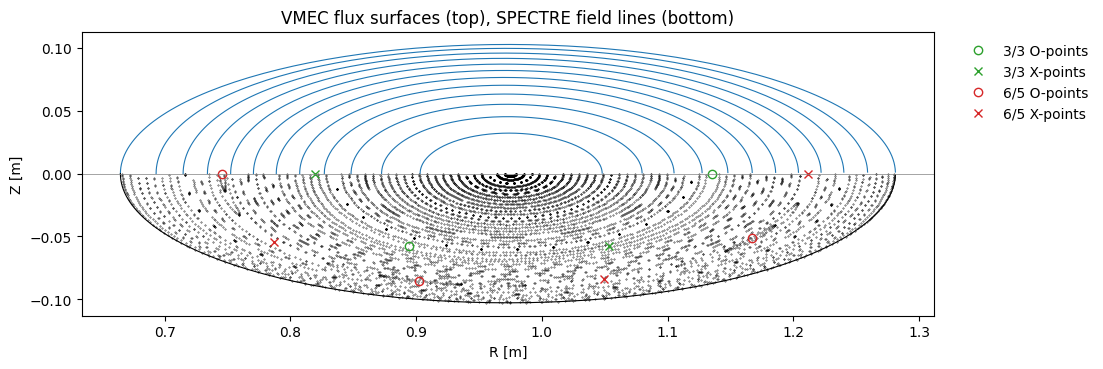

In [13]:
field = spectre.load_field(spectre_output)
field_lines = poincare_section(
    field, normalized_toroidal_angle=0.5, n_field_lines=50, n_punctures=300
)
points_of_chains = [
    chain_points(field, chain, on_half_period_plane=True) for chain in metrics.chains
]
_ = visualization.plot_poincare_section(
    equilibrium,
    field_lines,
    points_of_chains,
    chain_labels=[f"{chain.n}/{chain.m}" for chain in metrics.chains],
    normalized_toroidal_angle=0.5,
    figsize=(11, 4.5),
)

The rotational transform of the SPECTRE field, measured along field lines, follows VMEC's except inside the islands, where it is flat at the island's rational.

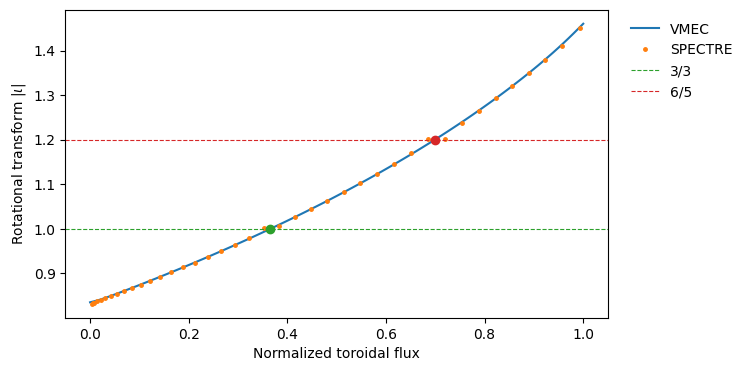

In [14]:
spectre_profile = rotational_transform_profile(field, equilibrium)
_ = visualization.plot_rotational_transform(
    equilibrium, metrics.crossings, spectre_profile, figsize=(7, 4)
)

## In one call

The forward model runs both steps when it is given SPECTRE settings, and returns the metrics with the others. It solves VMEC and SPECTRE again, so this cell is not run by default.

In [15]:
RUN_FORWARD_MODEL = False

if RUN_FORWARD_MODEL:
    settings = forward_model.ConstellarationSettings.default_high_fidelity_skip_qi()
    settings.spectre_settings = solver_settings
    all_metrics, _ = forward_model.forward_model(boundary, settings=settings)
    print(all_metrics.field_integrity.model_dump_json(indent=2, exclude={"crossings"}))